**ILOs**

After completing this lab you should be able to 

* understand NBC's factorisation, parameterisation, parameter estimation, and key algorithms
* implement a Naive Bayes text classifier
* predict and evaluate models using precision/recall
* use sklearn's vectorizer and Naive Bayes class

**Table of contents**

* [Labelled Data](#data)
* [Text Classifier](#textcls)
* [Generative Classifier](#gencls)
* [Naive Bayes Classifier](#NBC)
    * [Classification](#classification)
    * [Parameter Estimation](#MLE)
    * [Implementation](#code)
    * [Experiment](#exp)
* [scikit-learn](#sklearn)


**General notes**

* In this notebook you are expected to use $\LaTeX$. 
* Use python3.
* Use NLTK (3.5) to read annotated data.

**Tips**

* Check the entire notebook before you get started, this gives you an idea of what lies ahead.
* Note that, as always, the notebook recaps theory, and contains quizzes. While you should probably make use of this theory recap, be careful not to spend disproportionately more time on this than you should. The theory here is more condensed, and should be easier to understand after reading the corresponding textbook chapter (Chapter 4 on Perusall) and the highlights discussed in class (Week 6 - HC1).
* I recommend you read the theory part before the LC session if you can, aim at 1h investment, then work on the coding part during the LC, and if you can invest another hour or two of self-study (for example, to finish up the notebook or to just review it).

**Updates since first release**

* Fixed a bug in Laplace smoothing (the vocabulary size should be computed with respect to the complete vocabulary, not only the "vocabulary per class").
* Improved the speed of the sampling method by vectorizing the cpd once, and sampling many times in the same function.

# <a name="data"> Labelled Data

In this tutorial we will be looking into text classification with labelled data (that is, text that has been categorised or somehow labelled for certain attributes). 
    
This can be binary classification, for example, 

* `nltk.corpus.sentence_polarity`
* `nltk.corpus.movie_reviews`
* `nltk.corpus.subjectivity`    

In [1]:
#!pip install --upgrade nltk==3.5

In [2]:
from nltk.corpus import sentence_polarity
sentence_polarity.categories()

['neg', 'pos']

In [3]:
from nltk.corpus import movie_reviews
movie_reviews.categories()

['neg', 'pos']

In [4]:
from nltk.corpus import subjectivity
subjectivity.categories()

['obj', 'subj']

Let's inspect the first 10 sentences of each class in `sentence_polarity` and their average length:

In [5]:
import numpy as np

for x, y in zip(sentence_polarity.sents(categories=['pos']), ['+'] * 10):
    print(y, ' '.join(x))
print('Average number of tokens: {:.2f}'.format(np.array([len(x) for x in sentence_polarity.sents(categories=['pos'])]).mean()))

+ the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .
+ the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson's expanded vision of j . r . r . tolkien's middle-earth .
+ effective but too-tepid biopic
+ if you sometimes like to go to the movies to have fun , wasabi is a good place to start .
+ emerges as something rare , an issue movie that's so honest and keenly observed that it doesn't feel like one .
+ the film provides some great insight into the neurotic mindset of all comics -- even those who have reached the absolute top of the game .
+ offers that rare combination of entertainment and education .
+ perhaps no picture ever made has more literally showed that the road to hell is paved with good intentions .
+ steers turns in a snappy screenpla

In [6]:
for x, y in zip(sentence_polarity.sents(categories=['neg']), ['-'] * 10):
    print(y, ' '.join(x))
print('Average number of tokens: {:.2f}'.format(np.array([len(x) for x in sentence_polarity.sents(categories=['neg'])]).mean()))

- simplistic , silly and tedious .
- it's so laddish and juvenile , only teenage boys could possibly find it funny .
- exploitative and largely devoid of the depth or sophistication that would make watching such a graphic treatment of the crimes bearable .
- [garbus] discards the potential for pathological study , exhuming instead , the skewed melodrama of the circumstantial situation .
- a visually flashy but narratively opaque and emotionally vapid exercise in style and mystification .
- the story is also as unoriginal as they come , already having been recycled more times than i'd care to count .
- about the only thing to give the movie points for is bravado -- to take an entirely stale concept and push it through the audience's meat grinder one more time .
- not so much farcical as sour .
- unfortunately the story and the actors are served with a hack script .
- all the more disquieting for its relatively gore-free allusions to the serial murders , but it falls down in its attempts

We may have more than 2 classes, see documents in `nltk.corpus.brown`:

In [7]:
from nltk.corpus import brown
len(brown.categories())

15

Let's inspect 2 sentences/documents of each class and their average length:

In [8]:
from itertools import compress

for y in brown.categories():
    print("Label: '{}'".format(y))
    for x in compress(brown.sents(categories=[y]), [True] * 2):
        print(' '.join(x))
    print("Average number of tokens for '{}': {:.2f}\n".format(y, np.array([len(x) for x in brown.sents(categories=[y])]).mean()))

Label: 'adventure'
Dan Morgan told himself he would forget Ann Turner .
He was well rid of her .
Average number of tokens for 'adventure': 14.95

Label: 'belles_lettres'
Northern liberals are the chief supporters of civil rights and of integration .
They have also led the nation in the direction of a welfare state .
Average number of tokens for 'belles_lettres': 24.01

Label: 'editorial'
Assembly session brought much good
The General Assembly , which adjourns today , has performed in an atmosphere of crisis and struggle from the day it convened .
Average number of tokens for 'editorial': 20.56

Label: 'fiction'
Thirty-three
Scotty did not go back to school .
Average number of tokens for 'fiction': 16.12

Label: 'government'
The Office of Business Economics ( OBE ) of the U.S. Department of Commerce provides basic measures of the national economy and current analysis of short-run changes in the economic situation and business outlook .
It develops and analyzes the national income , bala

In this tutorial, **we will focus on sentiment classification** with 2 (positive and negative) or 3 classes (positive, negative, and neutral).

In [9]:
from tabulate import tabulate
from collections import Counter

# <a name="textcls"> Text Classifiers

A text classifier is a statistical model that reads text and categorises it as an instance of one of a finite set of classes.

Consider the case of *sentiment classification* with three sentiment levels (i.e., negative, neutral, and positive). 

A **probabilistic sentiment classifier** maps some piece of text $S \in \mathcal S$ to a probability distribution over the sample space $\mathcal Y = \{-1, 0, +1\}$, where -1 stands for negative, 0 stands for neutral, and +1 stands for positive sentiment. Note that we use $S$ (as in sentence), but it could be a paragraph, a document, or any granularity we like. As in the LM class, a piece of text $S$ will be seen as a sequence of words $S=X_{1:m}$.

Why does it make sense to see a classifier as a probability distribution? Well, there are a few technical reasons (we are generally very good at learning probability distributions, whereas other types of functions may be more difficult to learn), but here is an intuitive reason: probability distributions capture uncertainty due to the data, due to the task definition, or due to our inability to model the true underlying cognitive processes behind language understanding. See the example below.


We may say `no way` 
* in response to news about a global pandemic, in which case, we probably mean to express a negative sentiment about it;
* in response to our friend's startup being listed amongst the top-10 startups in the Netherlands, in which which we probably mean to express a positive sentiment about it;
* in response to a classmate asking `will you skip next NTMI's class?`, and in this case `no way` might just be an objective `no`, without a negative or positive sentiment.

If all we are given is the text `no way` and no additional context, nor any information about the speaker or the situation, then we cannot really determine the sentiment (not even as humans). This illustrates ambiguity/uncertainty that is inherent to the task/data. The best we can do is to pack a few assumptions into a model, use some data to estimate this model, and then let this model quantify the probability with which `no way` might express `negative`, `neutral`, or `positive` sentiment. 

As we said in the course, the probability of a certain sentiment $y \in \{-1, 0, 1\}$ given a piece of text $s$ is not a real attribute of $s$ in the world. It's nothing but a quantification of the uncertainty that a certain model of sentiment analysis can make given text and given all of the design assumptions we made. 


So, let's **design** one such model. We will pick sentiment analysis as the example, but other text classification problems fit in the same framework as long as the target classes come from a finite set of disjoint categories (e.g., sentiments, or topics, or types of named-entities, or spam vs not spam, or product categorisation in online shops, etc).


**Goal** We want a conditional distribution $P_{Y|S=s}$ that, given some piece of text $s$ (e.g., a sentence, a paragraph, or a document), quantifies our model's beliefs in each of the classes in the sample space $\mathcal Y$.

**Challenge** Think about it for a moment, we need a distribution over a finite number of classes, let's say we have $C$ classes. This should not be too difficult right? We have already learnt about the Categorical distribution, so we probably can simply do something like 

\begin{align}
    Y | S=s &\sim \mathrm{Cat}(\theta^{(s)}_{1:C})
\end{align}

That is, for each $s$, we have a $C$-dimensional probability vector $\theta^{(s)}_{1:C}$ where $\theta^{(s)}_{y}$ is the probability $P_{Y|S}(y|s, \boldsymbol \theta)$ that $s$ should be labelled with $y$.

**Quiz** What is the problem with attempting to use a tabular representation of the conditional distribution $Y|S=s$?

<details>
    <summary><b>SOLUTION</b></summary>
    
The tabular representation requires one $C$-dimensional parameter vector per unique occurrence of $s$. In our case, $s=x_{1:m}$ is a whole paragraph/document, this is seriously sparse. Imagine that most sentences occur exactly once in a corpus, imagine a whole paragraph. Let's think of movie reviews, it's almost certain that no two reviews look the exact same, even if they express the same sentiment about the movie. So the tabular representation will be too sparse, effectively impossible to estimate, and useless as a classifier. 
    
    
</details>

---

There are at least two different approaches to this problem. The *generative* approach, which we discuss in *this* notebook, and the *discriminative* approach, which you will encounter in A2.



# <a name="gencls"> Generative Classifiers

A generative classifier is a *joint distribution* $P_{SY}$ over the joint sample space $\mathcal S \times \mathcal Y$. We can use this model to *infer* a distribution $P_{Y|S=s}$ over target classes for any given $S=s$.

**Quiz** Suppose $\mathcal S$ is the space of all pieces of text (all of them, no matter the length). Suppose $\mathcal Y = \{-1, 0, 1\}$. Explain in words what the joint sample space $\mathcal S \times \mathcal Y$ consists of and give 2 examples of outcomes in it. How large this space is?







<details>
    <summary><b>SOLUTION</b></summary>
    
The joint sample space is made of the cross product of the two sets. As the set of all sentences is infinite, the joint sample space is also infinite. The elements in it are pairs of the kind $(s, y)$ where $s\in \mathcal S$ is a piece of text, and $y \in \mathcal Y$ is one of $3$ categories. Here are some examples of outcomes in it
    
* (`i love dogs`, +1)
* (`i love dogs`, 0)
* (`i love dogs`, -1) 
    
Note that all outcomes are in there, whether or not they are plausible, even something as unreasonable as (`cats are better than dogs`, +1) is in there, as well as ill-formed sentences (`i am i am i`, +1).
    
    
</details>

---

To specify a joint distribution that's tractable to estimate, once again, we start with the **chain rule**. The chain rule helps us re-express the task of drawing outcomes from an infinite space as a chain of simpler draws from finite spaces. 

**Joint distribution (first attempt)** 

\begin{align}
    P_{SY}(s,y) &= P_Y(y)P_{S|Y}(s|y)
\end{align}

This first attempt factors the probability of $y$ first, and then the probability of generating $x$ conditioned on $y$ being its label. This may seem counterintuitive at first, but imagine given that $y=-1$ you may indeed generate text that's very particular to negative sentiment, and not all too similar to what you would generate had $y$ been $+1$. Of course, there are exceptions to this, like our illustration with `no way`, but the intuition is still fairly reasonable. 

This factorisation does not *really* nail the problem. The second factor, $P_{S|Y}$ involves drawing from an infinite sample space still.

But hold on, unlike $P_{Y|S=s}$, which conditions on a very complex outcome, $P_{S|Y=y}$ conditions on a simple outcome (a class) and *generates* a complex outcome (text). Imagine we want to model $P_{S|Y=+1}$ for positive sentiment, this is just a conditional probability distribution over *text*. Recall that a conditional probability distribution is still a probability distribution.

**Quiz** How could we specify a distribution over text that is easy to estimate, easy to sample from, and easy to use in order to assess the probability of an outcome?

<details>
    <summary><b>SOLUTION</b></summary>
    
I really hope you said *we use a language model!* because that's exactly what we do!

We use chain rule to break the complex piece of text into smaller pieces, and make conditional independence assumptions to introduce cpds that are easy enough to estimate!
    
For example, let's make the conditional independence assumptions that any two words are independent of one another given the class.
    
Mathematically this is expressed as $X_i \perp X_j \mid Y=y$ for $i \neq j$ in $S=X_{1:m}$. 
    
And the factorisation becomes:    
    
\begin{align}
    P_{SY}(x_{1:m}, y) &\overset{\text{ind.}}{=} P_Y(y) \prod_{i=1}^m \underbrace{P_{X|Y}(x_i|y)}_{\text{simpler}}
\end{align}
    
    
</details>

---

# <a name="NBC"> Naive Bayes Classifier
    
The naive Bayes classifier (NBC) is called that way because it makes a strong conditional independence assumption and because it uses Bayes rule to infer the conditional probability $P_{Y|S}(y|s)$ from the joint distribution $P_{SY}$.

    
NBC factorises the **joint probability** of $(x_{1:m}, y)$ as:
    
\begin{align}
    P_{SY}(x_{1:m}, y) &\overset{\text{ind.}}{=} P_Y(y) \prod_{i=1}^m P_{X|Y}(x_i|y)
\end{align}

The simpler factor $P_Y$ is just a Categorical distribution over classes. The other, $P_{X|Y}$ is a collection of Categorical cpds. 
    
Here is the complete generative story as well as the parameterisation in terms of Categorical cpds:
    
1. Samples a target class $y$ from a prior distribution $Y \sim \mathrm{Cat}(\phi_{1:C})$ 
2. For each position $i$, conditions on $y$ and samples a word from a conditional distribution $X|Y=y \sim \mathrm{Cat}(\theta^{(y)}_{1:v})$ until you draw the EOS symbol.


Concretely, this is the probability value that the model assigns to a pair $(x_{1:m}, y)$:
    
\begin{align}
    P_{SY}(x_{1:m}, y|\boldsymbol \theta, \boldsymbol \phi) &\overset{\text{NBC}}{\triangleq} \underbrace{\mathrm{Cat}(y|\phi_{1:C})}_{=\phi_y} \prod_{i=1}^m \underbrace{\mathrm{Cat}(x_i|\theta^{(y)}_{1:v})}_{=\theta^{(y)}_{x_i}} \\
    &= \phi_y \prod_{i=1}^m \theta^{(y)}_{x_i}
\end{align}

**Quiz** What is the probability that the NBC assigns to (`no way`, +1)? How about (`no , no way`, -1)?

<details>
    <summary><b>SOLUTION</b></summary>
    
First, we pad the document with EOS symbol, i.e., we treat the document as `no way EOS`, then we plug into the formula for NBC getting 
    
\begin{equation}
    \phi_{+1} \times \theta^{(+1)}_{\text{no}} \times \theta^{(+1)}_{\text{way}} \times \theta^{(+1)}_{\text{EOS}}
\end{equation}
    
It's similar for the other case,     
\begin{equation}
    \phi_{-1} \times \left(\theta^{(-1)}_{\text{no}} \right)^2 \times \theta^{(-1)}_{\text{,}} \times \theta^{(-1)}_{\text{way}} \times \theta^{(-1)}_{\text{EOS}}
\end{equation}    
but note that we use a different cpd, this time conditioning on -1 rather than +1, we also have the probability of the comma (given -1), and the probability of `no` (given -1) factors in twice.     
    
</details>

---

**Quiz** If we interpreted the NBC as a probabilistic combination of a collection of $n$-gram language models, how many language models do we have, and of what kind?

<details>
    <summary><b>SOLUTION</b></summary>
    
The NBC combines $C$ unigram language models, one per class, each such unigram LM is conditioned on a particular value of the class variable. 
    
</details>

---

**Quiz** Can we use the NBC to assign probability to a document $x_{1:m}$ for which we do not know the class? If so, explain how and compute the probability of `no way`. 

<details>
    <summary><b>SOLUTION</b></summary>
    
The NBC is a joint distribution $P_{SY}$, if we are given only one outcome $S=x_{1:m}$, and not the other, we can always use *marginalisation* to compute $P_{S}(x_{1:m})$:
    
\begin{align}
    P_S(x_{1:m}|\boldsymbol \theta, \boldsymbol \phi) &= \sum_{y \in \mathcal Y} P_{SY}(x_{1:m}, y|\boldsymbol \theta, \boldsymbol \phi) \\
    &=  \sum_{y \in \mathcal Y} P_{Y}(y|\boldsymbol \phi) \prod_{i=1}^m P_{X|Y}(x_i|y, \boldsymbol \theta) \\
    &=  \sum_{y \in \mathcal Y} \phi_{y} \prod_{i=1}^m \theta^{(y)}_{x_i}
\end{align}
    
Then the probability of `no way` is
\begin{align}
    P_S(\langle \text{no}, \text{way}, \text{EOS} \rangle |\boldsymbol \theta, \boldsymbol \phi) 
    &= \phi_{-1} \times \theta^{(-1)}_{\text{no}} \times \theta^{(-1)}_{\text{way}} \times \theta^{(-1)}_{\text{EOS}} \\
    &+ \phi_{0} \times \theta^{(0)}_{\text{no}} \times \theta^{(0)}_{\text{way}} \times \theta^{(0)}_{\text{EOS}} \\
    &+\phi_{+1} \times \theta^{(+1)}_{\text{no}} \times \theta^{(+1)}_{\text{way}} \times \theta^{(+1)}_{\text{EOS}}
\end{align}
    
As a *language model*, you can think of this model as an interpolation of $C$ unigram LMs, each conditioned on a particular label. And the interpolation coefficients are given by the probability $\phi_y$ of each label.


**Warning** If this exercise was challenging, check out [Introduction to Directed Graphical Models](https://canvas.uva.nl/courses/21325/pages/directed-graphical-models?module_item_id=836817) and then try solving it again.
   
</details>

---

**Quiz** How do we obtain a target distribution $P_{Y|S=x_{1:m}}$ given some input text?

<details>
    <summary><b>SOLUTION</b></summary>
    
Via *Bayes rule*!
    
\begin{align}    
    P_{Y|S}(y|x_{1:m}) &= \frac{P_{SY}(x_{1:m}, y)}{P_{S}(x_{1:m})} \\
    &= \frac{P_Y(y)\prod_{i=1}^m P_{X|Y}(x_i|y)}{P_{S}(x_{1:m})} \\
\end{align}    

Note that we can compute all terms in this formula: $P_Y(y)$ is $\phi_y$, $P_{X|Y}(x_i|y)$ is $\theta^{(y)}_{x_i}$, and we've just solved $P_S(x_{1:m})$ in the previous exercise.
   
</details>

---

## <a name="classification"> Classification

How do we actually classify using the NBC? That's a fair question, and if you solved the previous quiz, you sort of already found the answer.


If we want to output our *best guess* at what class is most appropriate for some given text $x_{1:m}$, we can solve the following search problem:


\begin{align}
y^* &= \mathrm{argmax}_{y\in \mathcal Y} ~ P_{Y|X}(y|x_{1:m})
\end{align}

That is, we are looking for the class $y$ in $\mathcal Y$ that leads to maximum *posterior probability* $P_{Y|X}(y|x_{1:m})$.

Note that we do not have a cpd for $Y|X=x_{1:m}$, remember that would have been impossible to represent, and avoiding its need was the entire point behind generative modelling. Instead we have $P_Y$ and a collection of $P_{X|Y=y}$, one for each $y$, which we can combine into a joint distribution $P_{SY}$ due to chain rule and some conditional independence assumptions we made. 

With a *joint distribution* we can *always* invert any conditional operation, so even though we only have an efficient representation for $P_{S|Y=y}$, we can infer $P_{Y|S=x_{1:m}}$ for a given outcome of $S$.

This is what *Bayes rule* does, it inverts a conditional probability. In particular, the probability we are using to solve the search for our best guess $y^*$ is the posterior probability:

\begin{align}    
    P_{Y|S}(y|x_{1:m}, \boldsymbol \theta, \boldsymbol \phi) &= \frac{P_{SY}(x_{1:m}, y| \boldsymbol \theta, \boldsymbol \phi)}{P_{S}(x_{1:m}| \boldsymbol \theta, \boldsymbol \phi)} \\
    &= \frac{P_Y(y|\boldsymbol \phi)\prod_{i=1}^m P_{X|Y}(x_i|y, \boldsymbol \theta)}{\sum_{c \in \mathcal Y} P_{SY}(x_{1:m}, c|\boldsymbol \theta, \boldsymbol \phi)} \\
    &= \frac{P_Y(y|\boldsymbol \phi)\prod_{i=1}^m P_{X|Y}(x_i|y, \boldsymbol \theta)}{\sum_{c \in \mathcal Y} P_{Y}(c|\boldsymbol \phi) \prod_{i=1}^m P_{X|Y}(x_{i}|c, \boldsymbol \theta)} \\
    &= \frac{\phi_y \prod_{i=1}^m \theta^{(y)}_{x_i}}{\sum_{c \in \mathcal Y} \phi_{c} \prod_{i=1}^m \theta^{(c)}_{x_i} }
\end{align}  

Note that every factor in its computation can be looked up in one of our cpds, as the last identity shows. 

For classification however, note that the denominator is not relevant, and instead we can solve the following problem:

\begin{align}
y^* &= \mathrm{argmax}_{y\in \mathcal Y} ~ P_{Y|S}(y|x_{1:m}) \\
&= \mathrm{argmax}_{y\in \mathcal Y} ~ P_{SY}(x_{1:m}, y) \\
    &= \mathrm{argmax}_{y\in \mathcal Y} ~ P_Y(y)P_{S|Y}(x_{1:m}|y)
\end{align}

**Quiz** Why is the denominator of Bayes rule not relevant for predicting the most probable class?

<details>
    <summary><b>SOLUTION</b></summary>
    
In classification we search for which $y$ in $\mathcal Y$ has highest $P_{Y|S}(y|x_{1:m})$ for a **fixed** input $x_{1:m}$. By Bayes rule, this posterior probability is 
    
\begin{equation}    
    P_{Y|S}(y|x_{1:m}) = \frac{P_Y(y)P_{S|Y}(x_{1:m}| y)}{P_S(x_{1:m})}
\end{equation}    
    
and we can see that denominator is the same no matter the $y$. In other words, for determining the *mode of the posterior*, we do not need the denominator.
    
**Terminology** The mode of a discrete distribution is the outcome in its support for which the probability mass is largest. 
    
    
**Warning** The denominator is unnecessary to determine the best class, but to determine the *probability* of the best class (or of any of the classes), should we need that quantity for any reason, the denominator would be necessary.     
    
</details>

---

**Quiz** The logarithm is a monotone function, and therefore it does not change the result of argmax. Use this property to rewrite the objective function of the classification problem and express it in terms of the parameter $\boldsymbol \phi$ and $\boldsymbol \theta$ of our cpds.

<details>
    <summary><b>SOLUTION</b></summary>
    
We can write the optimisation problem as a function of the parameters of the model and apply log to transform products into sums:
    
\begin{align}
y^* &= \mathrm{argmax}_{y\in \mathcal Y} ~ P_{Y|S}(y|x_{1:m}, \boldsymbol \theta, \boldsymbol \phi) \\
&= \mathrm{argmax}_{y\in \mathcal Y} ~ P_{SY}(x_{1:m}, y|\boldsymbol \theta, \boldsymbol \phi) \\
&= \mathrm{argmax}_{y\in \mathcal Y} ~ P_Y(y|\boldsymbol \phi)P_{S|Y}(x_{1:m}|y, \boldsymbol \theta) \\
&= \mathrm{argmax}_{y\in \mathcal Y} ~ \log P_Y(y|\boldsymbol \phi) + \log \prod_{i=1}^m P_{X|Y}(x_i|y, \boldsymbol \theta) \\
&= \mathrm{argmax}_{y\in \mathcal Y} ~ \log \phi_y + \sum_{i=1}^m \log \theta^{(y)}_{x_i}
\end{align}
    
Adding log probabilities is more numerically convenient/stable than multiplying probabilities.     
    
</details>

---

## <a name="MLE"> Parameter Estimation

We know how NBC factorises, i.e., 

\begin{equation}
P_{SY}(x_{1:m}, y) = P_Y(y)\prod_{i=1}^m P_{X|Y}(x_i|y)
\end{equation}

we have chosen a parameterisation of our cpds, i.e., 

\begin{align}
P_{SY}(x_{1:m}, y|\boldsymbol \theta, \boldsymbol \phi) &= \mathrm{Cat}(y|\phi_{1:C})\prod_{i=1}^m \mathrm{Cat}(x_i|\theta^{(y)}_{1:v}) \\
&= \phi_{y} \prod_{i=1}^m \theta^{(y)}_{x_i}
\end{align}

now we need only estimate the numerical values of the parameters $\boldsymbol \phi$ and $\boldsymbol \theta$.

If we are given a dataset of $N$ labelled observations $\mathcal D = \{ (x^{(1)}_{1:m_1}, y^{(1)}), \ldots, (x^{(N)}_{1:m_N}, y^{(N)}) \}$, we can do so via maximum likelihood estimation.

**Quiz** What is the MLE for $\phi_{y}$ for some $y$ in $\mathcal Y$?

<details>
    <summary><b>SOLUTION</b></summary>
    
    
\begin{align}
\phi_y = \frac{\mathrm{count}_{Y}(y)}{\sum_{c \in \mathcal Y}\mathrm{count}_Y(c)} = \frac{\mathrm{count}_{Y}(y)}{N}
\end{align}
    
where we use $\mathcal D$ to determine the counts as shown below
    
\begin{equation}
    \mathrm{count}_Y(c) = \sum_{n=1}^N [y^{(n)} = c]
\end{equation}

For a *balanced* dataset, that is, a dataset with equal number of labelled instances for each class, $Y \sim \mathrm{Cat}(\phi_{1:C})$ becomes the uniform distribution, that is, $\phi_y = 1/C$ for all $y \in \mathcal Y$.
    
</details>

---

**Quiz** What is the MLE for $\theta^{(y)}_x$ for some $y$ in $\mathcal Y$ and $x$ in $\mathcal X$?

<details>
    <summary><b>SOLUTION</b></summary>
    
    
\begin{align}
\theta^{(y)}_{x} = \frac{\mathrm{count}_{YX}(y, x)}{\sum_{x' \in \mathcal X}\mathrm{count}_{YX}(y, x')}
\end{align}
    
where we use $\mathcal D$ to determine the counts as shown below
    
\begin{equation}
    \mathrm{count}_{YX}(c, w) = \sum_{n=1}^N \sum_{i=1}^m [y^{(n)} = c] \times [x^{(n)}_{i} = w]
\end{equation}
    
    
</details>

---

## <a name="code"> Implementation

    
We will design a python class that implements NBC, but before we get to code, let's check if you are getting comfortable with the formal presentation of the model (which is in principle enough to answer the following quizzes).

**Quiz** What is the time complexity of assessing joint probability $P_{SY}(x_{1:m}, y)$?

<details>
    <summary><b>SOLUTION</b></summary>
    
It takes $\mathcal O(m)$, since we have to assess $P_Y(y)$ once and $P_{X|Y=y}$ once for every word in $x_{1:m}$.
    
</details>

---

**Quiz** What is the time complexity of assessing marginal probability $P_S(x_{1:m})$?

<details>
    <summary><b>SOLUTION</b></summary>
    
It takes $\mathcal O(C \times m)$, since we need to assess the joint $P_{SY}(x_{1:m}, y)$ once for every label in the sample space $\{1, \ldots, C\}$. This is necessary so we can marginalise $Y$ out.
    
    
</details>

---

**Quiz** What is the storage requirements of the NBC model?

<details>
    <summary><b>SOLUTION</b></summary>
    
It requires space dominate by $\mathcal O(C \times v)$ since we have to store the $C$-dimensional vector $\phi_{1:C}$ and $C$ cpds, each defined over $v$ words.
    
    
</details>

---

**Quiz** What is the time complexity to classify $x_{1:m}$ with a trained model?

<details>
    <summary><b>SOLUTION</b></summary>
    
To classify, we need to assess the joint probability $P_{SY}(x_{1:m}, y)$ once for each label in the sample space $\{1, \ldots, C\}$, and then pick the maximum. This takes time $\mathcal O(C \times m)$ since each assessment of joint probability is linear in $m$.
    
    
</details>

---

There are a few special methods that are not implemented (but the solution appears in the cell after that)
* fit: which estimates the parameters $\boldsymbol \theta, \boldsymbol \phi$ of the classifier from labelled data
* predict: which makes predictions for unlabelled inputs    
* log_marginal_prob: which computes $P_S(x_{1:m}|\boldsymbol \theta, \boldsymbol \phi)$ for a given sentence
    
**Exercise** Complete the NBC class below    

In [10]:
import numpy as np
from collections import defaultdict, Counter
from itertools import chain, takewhile


class NaiveBayesClassifier:
    
    def __init__(self, labels, alpha, EOS='</s>', UNK='<unk>', seed=None):
        """
        :param labels: a list of classes, each a string or integer
        :param alpha: the smoothing coefficient for distributions of the kind X|Y=y
        :param EOS: the EOS symbol
        :param UNK: the UNK symbol for smoothing
        :param seed: random generator seed, fix this for reproducibility
        """
        self._EOS = EOS
        self._UNK = UNK
        self._alpha = alpha        
        self._labels = tuple(labels)
        self._rng = rng = np.random.RandomState(seed)  # Good for reproducibility
        self._vocab = set()
        
    def _get_smoothed_MLE(self, counts, vocab):        
        """
        Given a dictionary word -> counts, compute and return a smoothed probability vector.
        
        :param counts: a dictionary mapping each word to its count in the dataset
        :param vocab: the sample space of the variable X (that is, the whole vocabulary as a set)
        :return: a dictionary mapping each word to its probability
        """
        assert self._UNK not in counts, "This implementation takes care of UNK, you should not have added it to counts"

        # Smoothing parameters
        alpha = self._alpha
        v = len(vocab)
        if self._UNK not in vocab:  # Update: bug fix
            v += 1
            
        # Smoothed MLE
        probs = defaultdict(float)
        total = sum(counts.values())
             
        # Deal with observed words
        for w, n in counts.items():        
            probs[w] = (float(n) + alpha) / (total + alpha * v)
        # Deal with UNK
        probs[self._UNK] = alpha / (total + alpha * v)
            
        return probs
    
    def _get_theta(self, x, y):
        """Return theta[y][x] if x is known, otherwise theta[y][UNK]"""
        return self._theta[y].get(x, self._theta[y].get(self._UNK))
    
    def log_prior_prob(self, y):
        """Return log P(y)"""
        return np.log(self._phi[y])
        
    def log_conditional_prob(self, s, y):
        """
        Return log P(s|y)
        """
        return sum(np.log(self._get_theta(x, y)) for x in s)
    
    def log_joint_prob(self, s, y):
        """Return log P(y) + log P(s|y)"""
        return self.log_prior_prob(y) + self.log_conditional_prob(s, y)
     
    def log_marginal_prob(self, s):
        """Return log P(s) = log \sum_y P(s, y)"""
        # Tips:
        # * compute the joint probability for s and each of the possible labels
        #   marginalise (sum)
        #   compute log
        # * or, compute all of it in log space using log_joint_prob
        #   and np.logaddexp.reduce
        raise NotImplementedError("I am a quiz. Implement me or check the solution in the next cell.")
    
    def fit(self, data_s, data_y):
        """
        Estimate the parameters of an NBC model.
        
        :param data_s: a list of sentences, each sentence is a list of tokens (each token is a string)
        "param data_y: a list of labels, one label per sentence in data_s, a label is a string or an integer
    
        """
        
        # Tips 
        # * Begin by populating self._phi with the probabilities of the labels
        #   e.g., self._phi['pos'] = number of positive instances / total dataset size
        # * Then construct a vocabulary of unique tokens (and don't forget special tokens)
        #   e.g., self._vocab = {'these', 'are', 'the', 'tokens', 'in', 'all', 'documents', '</s>', '<unk>'}
        # * Then begin counting joint occurrences of words and labels
        #   e.g., joint_counts['pos']['nice'] = 10  # these are made up examples
        #   e.g., joint_counts['pos']['bad'] = 3
        # * Then use the counts to compute smoothed MLE for each cpd X|Y=y
        #   e.g., self._theta['pos']['nice'] 
        #    = (joint_counts['pos']['nice'] + alpha) / (total_counts_for_positive + alpha * vocab_size)        
        
        raise NotImplementedError("I am a quiz, implement me or check the solution in the next cell.")
    
    def predict(self, data_s):
        """
        :param data_x: a list of sentences to be classified, each sentence is a list of tokens (each token is a string)

        :return: a list of predictions, one per sentence in data_x, 
            each prediction is the label with highest posterior probability given the input
        """
        # Tips
        # * for each y, evaluate log p(s, y), then select the one that has highest value
        #   note that we have provided a helper method self.log_joint_prob(s, y)
        
        raise NotImplementedError("I am a quiz! Implement me or check the solution in the next cell.")        
    
    def sample_n(self, num_samples=1, y=None, max_length=200):  # UPDATE: Improved speed
        """
        Sample a number of times from the joint distribution, or from the conditional
        :param num_samples: how many samples do we want to generate
        :param y: if given, sample from S|Y=y, otherwise from Y and then from S|Y    
        :param max_length: maximum length for s
        :return: a generator of samples, each a pair (y, x)
        """
        if y is None:  # here we sample y from P_Y
            k = self._rng.choice(len(self._labels), p=[self._phi[y] for y in self._labels])
            y = self._labels[k]        
        s = []
        # here we make a probability vector for the conditional
        vocab = [w for w in self._vocab]
        probs = np.array([self._get_theta(w, y) for w in self._vocab])
        samples = []
        for _ in range(num_samples):
            # I know use numpy to sample max_length tokens following the distribution X|Y=y
            # I also map numpy's choices (which are indices) to words using `vocab`
            stream = [vocab[k] for k in self._rng.choice(probs.size, max_length, p=probs)]
            # Finally, I throw away whatever happens after the first occurrence of EOS
            # (this wastes a bit of computation, but it's okay for our demonstration)
            yield (y, list(takewhile(lambda x: x != self._EOS, stream)) )            

<details>
    <summary><b>SOLUTION</b></summary>

```python

import numpy as np
from collections import defaultdict, Counter
from itertools import chain, takewhile


class NaiveBayesClassifier:
    
    def __init__(self, labels, alpha, EOS='</s>', UNK='<unk>', seed=None):
        """
        :param labels: a list of classes, each a string or integer
        :param alpha: the smoothing coefficient for distributions of the kind X|Y=y
        :param EOS: the EOS symbol
        :param UNK: the UNK symbol for smoothing
        :param seed: random generator seed, fix this for reproducibility
        """
        self._EOS = EOS
        self._UNK = UNK
        self._alpha = alpha        
        self._labels = tuple(labels)
        self._rng = rng = np.random.RandomState(seed)  # Good for reproducibility
        self._vocab = set()
        
    def _get_smoothed_MLE(self, counts, vocab):        
        """
        Given a dictionary word -> counts, compute and return a smoothed probability vector.
        
        :param counts: a dictionary mapping each word to its count in the dataset
        :param vocab: the sample space of the variable X (that is, the whole vocabulary as a set)
        :return: a dictionary mapping each word to its probability
        """
        assert self._UNK not in counts, "This implementation takes care of UNK, you should not have added it to counts"

        # Smoothing parameters
        alpha = self._alpha
        v = len(vocab)
        if self._UNK not in vocab:
            v += 1
            
        # Smoothed MLE
        probs = defaultdict(float)
        total = sum(counts.values())
             
        # Deal with observed words
        for w, n in counts.items():        
            probs[w] = (float(n) + alpha) / (total + alpha * v)
        # Deal with UNK
        probs[self._UNK] = alpha / (total + alpha * v)
            
        return probs
    
    def _get_theta(self, x, y):
        """Return theta[y][x] if x is known, otherwise theta[y][UNK]"""
        return self._theta[y].get(x, self._theta[y].get(self._UNK))
    
    def log_prior_prob(self, y):
        """Return log P(y)"""
        return np.log(self._phi[y])
        
    def log_conditional_prob(self, s, y):
        """
        Return log P(s|y)
        """
        return sum(np.log(self._get_theta(x, y)) for x in s)
    
    def log_joint_prob(self, s, y):
        """Return log P(y) + log P(s|y)"""
        return self.log_prior_prob(y) + self.log_conditional_prob(s, y)
     
    def log_marginal_prob(self, s):
        """Return log P(s) = log \sum_y P(s, y)"""
        return np.logaddexp.reduce([self.log_joint_prob(s, y) for y in self._labels])
    
    def fit(self, data_s, data_y):
        """
        Estimate the parameters of an NBC model.
        
        :param data_s: a list of sentences, each sentence is a list of tokens (each token is a string)
        "param data_y: a list of labels, one label per sentence in data_s, a label is a string or an integer
    
        """
        
        # MLE for Y ~ Cat(phi)
        N = len(data_y)
        # count_Y(y) divided by total data points N (no need for smoothing here)
        self._phi = dict((y, float(n) / N) for y, n in Counter(data_y).items())
        
        # MLE for X|Y=y ~ Cat(theta^y)
        # Vocabulary (support of X)
        self._vocab = set(chain(*data_s))
        self._vocab.add(self._EOS)  # we need to pad sentences
        self._vocab.add(self._UNK)  # we will need Laplace smoothing
        
        # Counts for (X,Y)
        joint_counts = dict((y, Counter()) for y in self._labels)
        for s, y in zip(data_s, data_y):
            counter_x_given_y = joint_counts[y]
            counter_x_given_y.update(s + [self._EOS])  # we gotta pad our sentences with EOS
        
        # Parameters theta^y
        self._theta = dict()
        for y in self._labels:
            self._theta[y] = self._get_smoothed_MLE(joint_counts[y], self._vocab)
    
    def predict(self, data_s):
        """
        :param data_x: a list of sentences to be classified, each sentence is a list of tokens (each token is a string)

        :return: a list of predictions, one per sentence in data_x, 
            each prediction is the label with highest posterior probability given the input
        """
        y_pred = []
        for s in data_s:            
            best_k = np.argmax([self.log_joint_prob(s, y) for y in self._labels])
            y_pred.append(self._labels[best_k])
        return y_pred
    
    def sample_n(self, num_samples=1, y=None, max_length=200):
        """
        Sample a number of times from the joint distribution, or from the conditional
        :param num_samples: how many samples do we want to generate
        :param y: if given, sample from S|Y=y, otherwise from Y and then from S|Y    
        :param max_length: maximum length for s
        :return: a generator of samples, each a pair (y, x)
        """
        if y is None:  # here we sample y from P_Y
            k = self._rng.choice(len(self._labels), p=[self._phi[y] for y in self._labels])
            y = self._labels[k]        
        s = []
        # here we make a probability vector for the conditional
        vocab = [w for w in self._vocab]
        probs = np.array([self._get_theta(w, y) for w in self._vocab])
        samples = []
        for _ in range(num_samples):
            # I know use numpy to sample max_length tokens following the distribution X|Y=y
            # I also map numpy's choices (which are indices) to words using `vocab`
            stream = [vocab[k] for k in self._rng.choice(probs.size, max_length, p=probs)]
            # Finally, I throw away whatever happens after the first occurrence of EOS
            # (this wastes a bit of computation, but it's okay for our demonstration)
            yield (y, list(takewhile(lambda x: x != self._EOS, stream)) )            
    
```    
    
</details>    

In [11]:
import numpy as np
from collections import defaultdict, Counter
from itertools import chain, takewhile


class NaiveBayesClassifier:
    
    def __init__(self, labels, alpha, EOS='</s>', UNK='<unk>', seed=None):
        """
        :param labels: a list of classes, each a string or integer
        :param alpha: the smoothing coefficient for distributions of the kind X|Y=y
        :param EOS: the EOS symbol
        :param UNK: the UNK symbol for smoothing
        :param seed: random generator seed, fix this for reproducibility
        """
        self._EOS = EOS
        self._UNK = UNK
        self._alpha = alpha        
        self._labels = tuple(labels)
        self._rng = rng = np.random.RandomState(seed)  # Good for reproducibility
        self._vocab = set()
        
    def _get_smoothed_MLE(self, counts, vocab):        
        """
        Given a dictionary word -> counts, compute and return a smoothed probability vector.
        
        :param counts: a dictionary mapping each word to its count in the dataset
        :param vocab: the sample space of the variable X (that is, the whole vocabulary as a set)
        :return: a dictionary mapping each word to its probability
        """
        assert self._UNK not in counts, "This implementation takes care of UNK, you should not have added it to counts"

        # Smoothing parameters
        alpha = self._alpha
        v = len(vocab)
        if self._UNK not in vocab:
            v += 1
            
        # Smoothed MLE
        probs = defaultdict(float)
        total = sum(counts.values())
             
        # Deal with observed words
        for w, n in counts.items():        
            probs[w] = (float(n) + alpha) / (total + alpha * v)
        # Deal with UNK
        probs[self._UNK] = alpha / (total + alpha * v)
            
        return probs
    
    def _get_theta(self, x, y):
        """Return theta[y][x] if x is known, otherwise theta[y][UNK]"""
        return self._theta[y].get(x, self._theta[y].get(self._UNK))
    
    def log_prior_prob(self, y):
        """Return log P(y)"""
        return np.log(self._phi[y])
        
    def log_conditional_prob(self, s, y):
        """
        Return log P(s|y)
        """
        return sum(np.log(self._get_theta(x, y)) for x in s)
    
    def log_joint_prob(self, s, y):
        """Return log P(y) + log P(s|y)"""
        return self.log_prior_prob(y) + self.log_conditional_prob(s, y)
     
    def log_marginal_prob(self, s):
        """Return log P(s) = log \sum_y P(s, y)"""
        return np.logaddexp.reduce([self.log_joint_prob(s, y) for y in self._labels])
    
    def fit(self, data_s, data_y):
        """
        Estimate the parameters of an NBC model.
        
        :param data_s: a list of sentences, each sentence is a list of tokens (each token is a string)
        "param data_y: a list of labels, one label per sentence in data_s, a label is a string or an integer
    
        """
        
        # MLE for Y ~ Cat(phi)
        N = len(data_y)
        # count_Y(y) divided by total data points N (no need for smoothing here)
        self._phi = dict((y, float(n) / N) for y, n in Counter(data_y).items())
        
        # MLE for X|Y=y ~ Cat(theta^y)
        # Vocabulary (support of X)
        self._vocab = set(chain(*data_s))
        self._vocab.add(self._EOS)  # we need to pad sentences
        self._vocab.add(self._UNK)  # we will need Laplace smoothing
        
        # Counts for (X,Y)
        joint_counts = dict((y, Counter()) for y in self._labels)
        for s, y in zip(data_s, data_y):
            counter_x_given_y = joint_counts[y]
            counter_x_given_y.update(s + [self._EOS])  # we gotta pad our sentences with EOS
        
        # Parameters theta^y
        self._theta = dict()
        for y in self._labels:
            self._theta[y] = self._get_smoothed_MLE(joint_counts[y], self._vocab)
    
    def predict(self, data_s):
        """
        :param data_x: a list of sentences to be classified, each sentence is a list of tokens (each token is a string)

        :return: a list of predictions, one per sentence in data_x, 
            each prediction is the label with highest posterior probability given the input
        """
        y_pred = []
        for s in data_s:            
            best_k = np.argmax([self.log_joint_prob(s, y) for y in self._labels])
            y_pred.append(self._labels[best_k])
        return y_pred
    
    def sample_n(self, num_samples=1, y=None, max_length=200):
        """
        Sample a number of times from the joint distribution, or from the conditional
        :param num_samples: how many samples do we want to generate
        :param y: if given, sample from S|Y=y, otherwise from Y and then from S|Y    
        :param max_length: maximum length for s
        :return: a generator of samples, each a pair (y, x)
        """
        if y is None:  # here we sample y from P_Y
            k = self._rng.choice(len(self._labels), p=[self._phi[y] for y in self._labels])
            y = self._labels[k]        
        s = []
        # here we make a probability vector for the conditional
        vocab = [w for w in self._vocab]
        probs = np.array([self._get_theta(w, y) for w in self._vocab])
        samples = []
        for _ in range(num_samples):
            # I know use numpy to sample max_length tokens following the distribution X|Y=y
            # I also map numpy's choices (which are indices) to words using `vocab`
            stream = [vocab[k] for k in self._rng.choice(probs.size, max_length, p=probs)]
            # Finally, I throw away whatever happens after the first occurrence of EOS
            # (this wastes a bit of computation, but it's okay for our demonstration)
            yield (y, list(takewhile(lambda x: x != self._EOS, stream)) )   

Here is a **toy demonstration** to help you with debugging your code.

In [12]:
toy_nbc = NaiveBayesClassifier(['neg', 'pos'], alpha=0.01, seed=23)

In [13]:
toy_nbc.fit(
    [
        'this is bad'.split(), 
        'this is really good'.split(),
        'this is pretty good'.split(),
        'this is great'.split(),
    ], ['neg', 'pos', 'pos', 'pos'])

In [14]:
assert toy_nbc._phi == {'neg': 0.25, 'pos': 0.75},  "Note the toy example has 1 negative and 3 positive instances, so we expect 1/4 and 3/4 as probability, not: {}".format(toy_nbc._phi)

In [15]:
assert toy_nbc._vocab == {'</s>', '<unk>', 'bad', 'good', 'great', 'is', 'pretty', 'really', 'this'}, "Did you perhaps forget to create a vocab or to add the UNK and EOS tokens?" 

In [16]:
assert toy_nbc._get_theta('pretty', 'neg') == toy_nbc._get_theta('<unk>', 'neg'), "The word 'pretty' was never seen by"

Note that the distributions should normalise over the complete sample space (which includes EOS and UNK):

In [17]:
assert np.isclose(sum(toy_nbc._get_theta(w, 'neg') for w in toy_nbc._vocab), 1, 1e-3), "Did you smooth things correctly? Try again with alpha=0.0, then see if you can fix it for alpha > 0.0"

In [18]:
assert np.isclose(sum(toy_nbc._get_theta(w, 'pos') for w in toy_nbc._vocab), 1, 1e-3), "Did you smooth things correctly? Try again with alpha=0.0, then see if you can fix it for alpha > 0.0"

In [19]:
toy_pred = toy_nbc.predict(
    [
        'this is really bad'.split(), 
        'this is good'.split(), 
        'this is pretty'.split()
    ]
)
assert toy_pred == ['neg', 'pos', 'pos'], "Something seems to have gone wrong with your predictions"

In [20]:
assert toy_nbc.log_conditional_prob('this is really bad'.split(), 'neg') > toy_nbc.log_conditional_prob('this is really bad'.split(), 'pos'), "The negative LM likes this sentence more"

In [21]:
assert toy_nbc.log_conditional_prob('this is really bad'.split(), 'neg') >  toy_nbc.log_marginal_prob('this is really bad'.split()) > toy_nbc.log_conditional_prob('this is really bad'.split(), 'pos'), "The marginal probability is in between"

We can sample from generative models. See how about 3/4 of the samples will be positive:

In [22]:
# Random generation:
for y, s in toy_nbc.sample_n(10):
    print('{}: {}'.format(y, ' '.join(s)))
    
print('\nOut of 100 samples we have {} positive.'.format(sum(1 for y, s in toy_nbc.sample_n(100) if y == 'pos')))

pos: pretty
pos: 
pos: is
pos: this really this great
pos: pretty good is this really good is pretty this pretty really
pos: 
pos: this
pos: really good this pretty is is
pos: really this is pretty this this great great really this
pos: this is this

Out of 100 samples we have 100 positive.


We can also sample conditionally, that is, given a particular label (we will be sampling from a specific unigram LM):

In [23]:
for y, s in toy_nbc.sample_n(10, y='pos'):
    print('{}: {}'.format(y, ' '.join(s)))

print('\nAverage length in 100 positive samples is {:.2f}'.format(sum(len(s) for y, s in toy_nbc.sample_n(100, y='pos'))/100.))    

pos: this this great great this
pos: 
pos: this this really this this
pos: this really really
pos: this good
pos: great good great really pretty this
pos: good this good pretty good pretty this good this this is
pos: pretty this is really this
pos: good really good this this good great is
pos: this is this

Average length in 100 positive samples is 4.67


Also for negative:

In [24]:
for y, s in toy_nbc.sample_n(10, y='neg'):
    print('{}: {}'.format(y, ' '.join(s)))

print('\nAverage length in 100 positive samples is {:.2f}'.format(sum(len(s) for y, s in toy_nbc.sample_n(100, y='neg'))/100.))    

neg: is
neg: is this bad
neg: is
neg: this
neg: 
neg: bad bad this is bad bad this
neg: 
neg: this bad bad great is bad bad is
neg: 
neg: 

Average length in 100 positive samples is 2.65


## <a name="exp">  Experiment


We will now try our NBC on one of NLTK's datasets.

As usual, we will need training data, development data, and test data:

In [25]:
import numpy as np
from itertools import chain


def split_corpus(sentences, ratio=0.9):
    """
    Randomly split a list of sentences into two sets according to the given ratio.
    
    :param sentences: already tokenized sentences (list of strings)
    """
    # This will guarantee that the permutation is the same every time (which is important for reproducibility)
    rng = np.random.RandomState(42)    
    indices = rng.permutation(len(sentences))
    n = int(indices.size * ratio)
    return [sentences[i] for i in indices[:n]], [sentences[i] for i in indices[n:]]

Let's attempt to predict sentence polarity

In [26]:
from nltk.corpus import sentence_polarity

pos_sents = sentence_polarity.sents(categories='pos')
neg_sents = sentence_polarity.sents(categories='neg')
print(len(pos_sents), 'positive sentences such as:\n', ' '.join(pos_sents[0]))
print(len(neg_sents), 'negative sentences such as:\n', ' '.join(neg_sents[0]))

5331 positive sentences such as:
 the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .
5331 negative sentences such as:
 simplistic , silly and tedious .


And here is a reasonable split:

In [27]:
training_pos, dev_pos = split_corpus(pos_sents, 0.8)
dev_pos, test_pos = split_corpus(dev_pos, 0.5)
training_neg, dev_neg = split_corpus(neg_sents, 0.8)
dev_neg, test_neg = split_corpus(dev_neg, 0.5)

In [28]:
rows = [
    ['pos', len(training_pos), len(dev_pos), len(test_pos)],
    ['neg', len(training_neg), len(dev_neg), len(test_neg)]
]
print(tabulate(rows, headers=['Label', 'Training', 'Development', 'Test']))

Label      Training    Development    Test
-------  ----------  -------------  ------
pos            4264            533     534
neg            4264            533     534


**Exercise** Fit NBC, evaluate it on dev set, report a confusion matrix, and accuracy.

<details>
    <summary><b>SOLUTION</b></summary>

```python
nbc = NaiveBayesClassifier(['neg', 'pos'], alpha=1.0)
nbc.fit(training_pos + training_neg, ['pos'] * len(training_pos) + ['neg'] * len(training_neg))
pred_pos = nbc.predict(dev_pos)
tp = sum(y == 'pos' for y in pred_pos)  # we predicted positive, and it was positive
fn = len(dev_pos) - tp  # we predicted negative, but it should have been positive
pred_neg = nbc.predict(dev_neg)
tn = sum(y == 'neg' for y in pred_neg)   # we predicted negative, and it was negative
fp = len(dev_neg) - tn  # we predicted positive, but it should have been negative
rows = [
    ['pos', tp, fp],
    ['neg', fn, tn]
]
print(tabulate(rows, headers=['prediction', 'pos', 'neg']))
print('\nAccuracy {:.2f}'.format((tp+tn)/(tp+fp+tn+fn)))
```
    
</details>

---

In [29]:
nbc = NaiveBayesClassifier(['neg', 'pos'], alpha=1.0)
nbc.fit(training_pos + training_neg, ['pos'] * len(training_pos) + ['neg'] * len(training_neg))
pred_pos = nbc.predict(dev_pos)
tp = sum(y == 'pos' for y in pred_pos)  # we predicted positive, and it was positive
fn = len(dev_pos) - tp  # we predicted negative, but it should have been positive
pred_neg = nbc.predict(dev_neg)
tn = sum(y == 'neg' for y in pred_neg)   # we predicted negative, and it was negative
fp = len(dev_neg) - tn  # we predicted positive, but it should have been negative
rows = [
    ['pos', tp, fp],
    ['neg', fn, tn]
]
print(tabulate(rows, headers=['prediction', 'pos', 'neg']))
print('\nAccuracy {:.2f}'.format((tp+tn)/(tp+fp+tn+fn)))

prediction      pos    neg
------------  -----  -----
pos             403    118
neg             130    415

Accuracy 0.77


**Exercise** Gather some samples from this NBC model and plot statistics such as average length and distribution of frequent sentiment words (nltk has an opinion lexicon of sentiment words, see below).

In [30]:
from nltk.corpus import opinion_lexicon

In [31]:
positive = set(opinion_lexicon.positive())
negative = set(opinion_lexicon.negative())

In [32]:
len(positive), len(negative), len(positive & negative)

(2006, 4783, 3)

<details>
    <summary><b>SOLUTION</b></summary>
   
These are examples of what you could do, feel free to try other things too.
    
```python
    
# Random generation: this will take a minute or two
samples_pos = [s for y, s in nbc.sample_n(len(training_pos), y='pos')]  # UPDATE: this is faster
samples_neg = [s for y, s in nbc.sample_n(len(training_neg), y='neg')]  # UPDATE: this is faster
print('Samples:', len(samples_pos), len(samples_neg))

# Average length
rows = [
    ['training', np.array([len(s) for s in training_pos]).mean(), np.array([len(s) for s in training_neg]).mean()],
    ['samples', np.array([len(s) for s in samples_pos]).mean(), np.array([len(s) for s in samples_neg]).mean()]
]
print("Average sentence length")
print(tabulate(rows, headers=['corpus', 'positive', 'negative']))

# Frequent sentiment words
counts_pos = Counter(chain(*samples_pos))
counts_neg = Counter(chain(*samples_neg))

rows_pos = []
for w in positive:
    if counts_pos.get(w, 0) > 5 or counts_neg.get(w, 0) > 5:
        rows_pos.append([w, counts_pos.get(w, 0), counts_neg.get(w, 0)])
print("Positive words and their occurrences in generated samples")    
print(tabulate(rows_pos, headers=['positive word', 'positive', 'negative']))

from matplotlib import pyplot as plt

_ = plt.plot(np.arange(len(rows_pos)), np.array([r[1] for r in rows_pos]), '+')
_ = plt.plot(np.arange(len(rows_pos)), np.array([r[2] for r in rows_pos]), '_')
_ = plt.xlabel("Frequent positive words")
_ = plt.ylabel("Occurrences in sample")
_ = plt.title("Sentences sampled from S|Y=+ contain more positive words")
_ = plt.show()

rows_neg = []
for w in negative:
    if counts_pos.get(w, 0) > 5 or counts_neg.get(w, 0) > 5:
        rows_neg.append([w, counts_pos.get(w, 0), counts_neg.get(w, 0)])
print("Negative words and their occurrences in generated samples")    
print(tabulate(rows_neg, headers=['negative word', 'positive', 'negative']))

_ = plt.plot(np.arange(len(rows_neg)), np.array([r[1] for r in rows_neg]), '+')
_ = plt.plot(np.arange(len(rows_neg)), np.array([r[2] for r in rows_neg]), '_')
_ = plt.xlabel("Frequent negative words")
_ = plt.ylabel("Occurrences in sample")
_ = plt.title("Sentences sampled from S|Y=- contain more negative words")
_ = plt.show()

    
```    
    
</details>    

---

Samples: 4264 4264
Average sentence length
corpus      positive    negative
--------  ----------  ----------
training     20.97       21.0321
samples      25.7477     25.6353
Positive words and their occurrences in generated samples
positive word       positive    negative
----------------  ----------  ----------
fascinating               45          13
charming                  30          16
breakthrough               7           4
willing                    9           5
quiet                     16           6
fun                       86          50
greatest                  14           2
strong                    22          25
great                     84          47
neatly                     6           1
profoundly                 6           1
distinctive                8           1
satisfying                24          12
amazingly                  6           4
smarter                   11           3
humorous                  10           2
magic                     20 

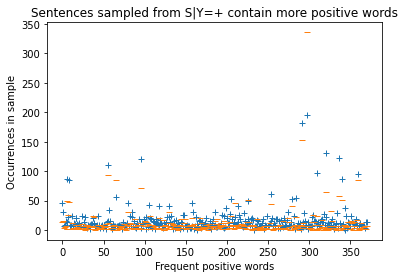

Negative words and their occurrences in generated samples
negative word      positive    negative
---------------  ----------  ----------
slow                     24          30
worst                     9          48
uneasily                  3           6
issue                     4           9
bored                     5           6
freaks                    6           6
feeble                    1           7
mediocre                  2          23
flee                      6           0
loud                      2          26
mad                       6           6
volatile                  6           2
sour                      2          10
lousy                     2           8
strange                  20          14
spooky                   10           3
heedless                  0           6
scary                     8          23
nasty                     6          10
improbable                5           8
sobering                  6           1
strangely             

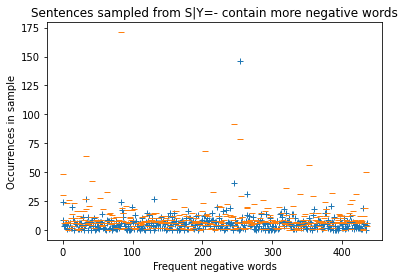

In [33]:
# Random generation: this will take a minute or two
samples_pos = [s for y, s in nbc.sample_n(len(training_pos), y='pos')]  # UPDATE: this is faster
samples_neg = [s for y, s in nbc.sample_n(len(training_neg), y='neg')]  # UPDATE: this is faster
print('Samples:', len(samples_pos), len(samples_neg))

# Average length
rows = [
    ['training', np.array([len(s) for s in training_pos]).mean(), np.array([len(s) for s in training_neg]).mean()],
    ['samples', np.array([len(s) for s in samples_pos]).mean(), np.array([len(s) for s in samples_neg]).mean()]
]
print("Average sentence length")
print(tabulate(rows, headers=['corpus', 'positive', 'negative']))

# Frequent sentiment words
counts_pos = Counter(chain(*samples_pos))
counts_neg = Counter(chain(*samples_neg))

rows_pos = []
for w in positive:
    if counts_pos.get(w, 0) > 5 or counts_neg.get(w, 0) > 5:
        rows_pos.append([w, counts_pos.get(w, 0), counts_neg.get(w, 0)])
print("Positive words and their occurrences in generated samples")    
print(tabulate(rows_pos, headers=['positive word', 'positive', 'negative']))

from matplotlib import pyplot as plt

_ = plt.plot(np.arange(len(rows_pos)), np.array([r[1] for r in rows_pos]), '+')
_ = plt.plot(np.arange(len(rows_pos)), np.array([r[2] for r in rows_pos]), '_')
_ = plt.xlabel("Frequent positive words")
_ = plt.ylabel("Occurrences in sample")
_ = plt.title("Sentences sampled from S|Y=+ contain more positive words")
_ = plt.show()

rows_neg = []
for w in negative:
    if counts_pos.get(w, 0) > 5 or counts_neg.get(w, 0) > 5:
        rows_neg.append([w, counts_pos.get(w, 0), counts_neg.get(w, 0)])
print("Negative words and their occurrences in generated samples")    
print(tabulate(rows_neg, headers=['negative word', 'positive', 'negative']))

_ = plt.plot(np.arange(len(rows_neg)), np.array([r[1] for r in rows_neg]), '+')
_ = plt.plot(np.arange(len(rows_neg)), np.array([r[2] for r in rows_neg]), '_')
_ = plt.xlabel("Frequent negative words")
_ = plt.ylabel("Occurrences in sample")
_ = plt.title("Sentences sampled from S|Y=- contain more negative words")
_ = plt.show()

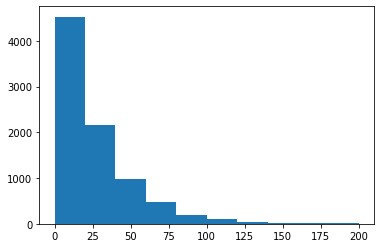

In [51]:
_ = plt.hist(np.array([len(s) for y, s in nbc.sample_n(len(training_pos) + len(training_neg))]))

## Error analysis 

Our NBC's performance on devset is roughly as follows

```
              truth
              ------------
prediction      pos    neg
------------  -----  -----
pos             403    119
neg             130    414

Accuracy 0.77
```

This is a [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix), it displays a summary of our predictions in terms of true positives (TP), false positive (FP), false negative (FN), and true negatives (TN). 




**Exercise** Inspect some of the mistakes (FP or FN) and speculate about directions for improvement.

<details>
    <summary><b>SOLUTION</b></summary>
        
```python
from itertools import compress
print("# FN")
for s in compress([s for y_pred, s in zip(pred_pos, dev_pos) if y_pred == 'neg'], [True] * 10):
    print(' '.join(s))
    print()

print("# FP")
for s in compress([s for y_pred, s in zip(pred_pos, dev_pos) if y_pred == 'pos'], [True] * 10):
    print(' '.join(s))
    print()
```        

</details>

---


You probably noticed different types of ambiguity. For example, some words and expressions are ambiguous in *scope*. 

For example, `bad` may be generally negative, but `not so bad` is not as negative, and `not bad` is actually good.

Other cases are even more subtle:

* `the cast is amazing , but the plot ...`  here `but` changes the overall sentiment of the sentence

A simple heuristic to resolve some of these ambiguities is to mark the tokens with a special tag, indicating the scope. So for example `this is not so bad` might become `this is not so_NOT bad_NOT`, or `the cast is amazing , but the plot ...` might become `the_BUT cast_BUT is_BUT amazing_BUT , but the plot ...`.

These heuristics are not easy to define as you can see, lots of exceptions, very language specific, etc.

For English, you can design some. For example, `nltk.sentiment.util.mark_negation` implements one simple heuristic for negation scope. It's not very robust, but we could use it just to illustrate the strategy. 

Modern NLP (as we will see after the midterm) dispenses with this kind of heuristic, instead we use powerful models that can tractably handle weaker independence assumptions. 

**Exercise** Test whether NLTK's `mark_negation` can help with some of the FP or FN without reducing TP or TN.

In [34]:
from nltk.sentiment import util

In [35]:
util.mark_negation('this is not a bad film'.split())

['this', 'is', 'not', 'a_NEG', 'bad_NEG', 'film_NEG']

<details>
    <summary><b>SOLUTION</b></summary>
        
    
```python

nbc2 = NaiveBayesClassifier(['neg', 'pos'], alpha=1.0)
nbc2.fit(
    [util.mark_negation(s) for s in training_pos + training_neg], 
    ['pos'] * len(training_pos) + ['neg'] * len(training_neg)
)
pred_pos2 = nbc2.predict([util.mark_negation(s, True) for s in dev_pos])
tp = sum(y == 'pos' for y in pred_pos2)  # we predicted positive, and it was positive
fn = len(dev_pos) - tp  # we predicted negative, but it should have been positive
pred_neg2 = nbc2.predict([util.mark_negation(s) for s in dev_neg])
tn = sum(y == 'neg' for y in pred_neg2)   # we predicted negative, and it was negative
fp = len(dev_neg) - tn  # we predicted positive, but it should have been negative
rows = [
    ['pos', tp, fp],
    ['neg', fn, tn]
]
print(tabulate(rows, headers=['prediction', 'pos', 'neg']))
print('\nAccuracy {:.2f}'.format((tp+tn)/(tp+fp+tn+fn)))


```

This is what I got

```
prediction      pos    neg
------------  -----  -----
pos             408    122
neg             125    411

Accuracy 0.77
```

</details>

---

# <a name="sklearn"> scikit-learn


For more interesting experiments, we better use [scikit-learn (sklearn)](https://scikit-learn.org), which deploys many ML solutions for us.

In sklearn, we have classes with two important methods `fit` and `predict`, just like our own NBC.
Unlike our own NBC, sklearn takes vectorized data (and deals with sparsity in a different way, with sophisticated data structures from scipy). We don't need to know the internals of these data structures, but it's useful to learn how to create them and how to manipulate them when needed.

First, let's make sure we have a training/dev/test split that has been properly randomized.
For convenience, we will pair the document and its label, and we will convert the document from list of strings to a single string (by joining with space), see below.

In [36]:
def prepare_corpus(nltk_corpus, categories, seed=23, EOS='</s>'):
    """
    Prepare an nltk text categorization corpus in a sklearn friendly format
    
    :param nltk_corpus: something like sentence_polarity
    :param categories: a list of categories (each a string), 
        sklearn will treat categories as 0-based integers, thus we will map the ith element in this list to y=i
    :param seed: for reproducibility
    """
    pairs = []    
    for y, label in enumerate(categories):  # here we pair doc (as a single string) and id of label (as int)
        # this time we will concatenate the EOS symbol to the string
        pairs.extend((' '.join(s + [EOS]), y) for s in nltk_corpus.sents(categories=[label]))
    # we turn the pairs into a numpy array
    # np arrays are very convenient for the indexing tools np provides, as we will see
    pairs = np.array(pairs)
    # it's good to shuffle the pairs
    rng = np.random.RandomState(seed)    
    rng.shuffle(pairs)
    # let's split the np array into training (80%), dev (10%), and test (10%)
    num_pairs = pairs.shape[0]
    # we can use slices to select the first 80% of the rows
    training = pairs[0:int(num_pairs * 0.8),:]
    # and similarly for the next 10%
    dev = pairs[int(num_pairs * 0.8):int(num_pairs * 0.9),:]
    # and for the last 10%
    test = pairs[int(num_pairs * 0.9):,:] 
    return training, dev, test

In [37]:
training, dev, test = prepare_corpus(sentence_polarity, ['neg', 'pos']) # 0:negative, 1: positive

In [38]:
training.shape, dev.shape, test.shape

((8529, 2), (1066, 2), (1067, 2))

In [39]:
# This is what the first 5 training instances look like
print(training[0:5, 0])

["imagine the cleanflicks version of 'love story , ' with ali macgraw's profanities replaced by romance-novel platitudes . </s>"
 'as broad and cartoonish as the screenplay is , there is an accuracy of observation in the work of the director , frank novak , that keeps the film grounded in an undeniable social realism . </s>'
 'the result is solemn and horrifying , yet strangely detached . </s>'
 'starts as a tart little lemon drop of a movie and ends up as a bitter pill . </s>'
 'the entire film is one big excuse to play one lewd scene after another . about half of them are funny , a few are sexy and none are useful in telling the story , which is paper-thin and decidedly unoriginal . </s>']


In [40]:
# and these are their labels
print(training[0:5, 1])

['0' '1' '0' '0' '0']


To represent categorical data efficiently, sklearn uses *vectorizers*. These are classes the turn a string into a sparse vector of coded features. Internally this builds a vocabulary of features and a data structure that is sparse like nested dicts, but much more efficient.

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

Take a moment to read the documentation of `CountVectorizer?` and play a bit with some examples.

The count vectorizer can be used to implement NBC. We simply need to count the unigrams, which in sklearn style is done as follows:

In [42]:
vectorizer = CountVectorizer(ngram_range=(1,1))

We should then *train* our vectorizer, this essentially builds the vocabulary of features and prepares the sparse data structures:

In [43]:
vectorizer.fit(training[:,0])  # we must give it all of our text (all rows, first colum of training)

CountVectorizer()

Now that it's trained, we can use it to vectorize our training data, or dev data, or test data:

In [44]:
vectorizer.transform(dev[:, 0])  # this returns a sparse matrix of unigram counts for all instances in the dev set

<1066x16543 sparse matrix of type '<class 'numpy.int64'>'
	with 16885 stored elements in Compressed Sparse Row format>

sklearn has its own implementation of NBC, for the count features we have this is called `sklearn.naive_bayes.MultinomialNB`. Take a moment to check its documentation.

In [45]:
from sklearn.naive_bayes import MultinomialNB

In [46]:
cls = MultinomialNB(alpha=1.0)  # just like our own NBC it takes a smoothing parameter

Given vectorized documents and their categories (as integers), we can fit the parameters of the model:

In [47]:
cls.fit(vectorizer.transform(training[:,0]), training[:,1])

MultinomialNB()

and with vectorized documents we can predict the best labels according to the model:

In [48]:
y_pred = cls.predict(vectorizer.transform(dev[:,0]))

In [49]:
print('Dev accuracy {:.2f}'.format((y_pred == dev[:,1]).mean()))

Dev accuracy 0.78


Using sklearn allows us to take advantage of its featurizers. See that CountVector can use lists of stopwords, 
and it can even use bigrams (or more).

Vectorizing with unigrams and bigrams would imply modifying the factorisation of the NBC, in particular, it's conditional $P_{S|Y=y}$ would become more complex, and all that without having to reimplment NBC itself!

**Exercise** Try a few of these options and see if you can improve the baseline dev score. Then try it on the test set.

<details>
    <summary><b>SOLUTION</b></summary>
    
This is just one example, you could try many other things:    
    
```python
from tabulate import tabulate


def grid_search(training, dev, test):  # sklearn does offer a grid-search procedure, but we will learn about it in A2
    best = None
    rows = []
    for max_ngram in [1, 2]: # let's try unigrams and bigrams
        # train featurizer
        vectorizer = CountVectorizer(ngram_range=(1, max_ngram))
        vectorizer.fit(training[:, 0])
        # transform inputs
        training_inputs = vectorizer.transform(training[:,0])
        dev_inputs = vectorizer.transform(dev[:,0])
        for alpha in np.arange(0.1, 1.5, 0.1): # let's test a space of alphas       
            # train classifier
            cls = MultinomialNB(alpha=alpha)
            cls.fit(training_inputs, training[:, 1])
            # assess dev accuracy
            pred_dev = cls.predict(dev_inputs)
            rows.append([max_ngram, alpha, (pred_dev == dev[:,1]).mean()])
            if best is None:
                best = rows[-1]
            elif best[-1] < rows[-1][-1]:
                best = rows[-1]  
                
    print(tabulate(rows, headers=['n-gram', 'alpha', 'dev accuracy']))
    
    # re-trains the best configuration and return it
    vectorizer = CountVectorizer(ngram_range=(1, best[0]))
    vectorizer.fit(training[:, 0])
    cls = MultinomialNB(alpha=best[1])
    cls.fit(vectorizer.transform(training[:, 0]), training[:, 1])
    # predict labels for test set
    pred_test = cls.predict(vectorizer.transform(test[:, 0]))
    return best, vectorizer, cls, pred_test
print("Grid search")
best, vectorizer, cls, pred_test = grid_search(training, dev, test)
print("Best model")
print(tabulate([best + [(pred_test == test[:, 1]).mean()]], headers=['ngram', 'alpha', 'dev', 'test']))    
```
    
</details>    